In [ ]:
from helper import base_model_dir, output_dir
from mflux.models.flux.variants.txt2img.flux import Flux1
from mflux.models.flux2 import Flux2Klein

In [2]:
def get_model(
    model_name: str,
    quantize: int = 0,
    to_save_model: bool = False,
    **model_kwargs,
):
    model_kwargs = {}
    if quantize:
        model_kwargs["quantize"] = quantize

    builder = Flux1
    if model_name.lower().startswith("flux.2"):
        builder = Flux2Klein

    model_path = base_model_dir / model_name
    model = builder(
        model_path=str(model_path),
        **model_kwargs,
    )

    if to_save_model and quantize:
        export_path = base_model_dir / f"{model_name}-mflux-{quantize}bit"
        model.save_model(str(export_path))
        # model.save_weights(str(export_path / "model.safetensors"))

    return model

In [3]:
lora_path = base_model_dir / "lora" / "flux.1" / "lora.safetensors"

# model = get_model(
#     "FLUX.1-dev",
#     quantize=6,
#     # to_save_model=True,
# )
model = get_model(
    "FLUX.1-dev-mflux-6bit",
    # lora_paths=[str(lora_path)],
    # lora_scales=[0.5],
)

# model = get_model(
#     "FLUX.2-klein-9b",
#     quantize=6,
#     # to_save_model=True,
# )

In [4]:
images = model.generate_image(
    prompt="A puffin standing on a cliff",
    width=1024,
    height=1024,
    num_inference_steps=8,
    seed=0,
)
images.image.save(output_dir / "puffin-flux1.png")
images

100%|██████████| 8/8 [00:54<00:00,  6.87s/it]


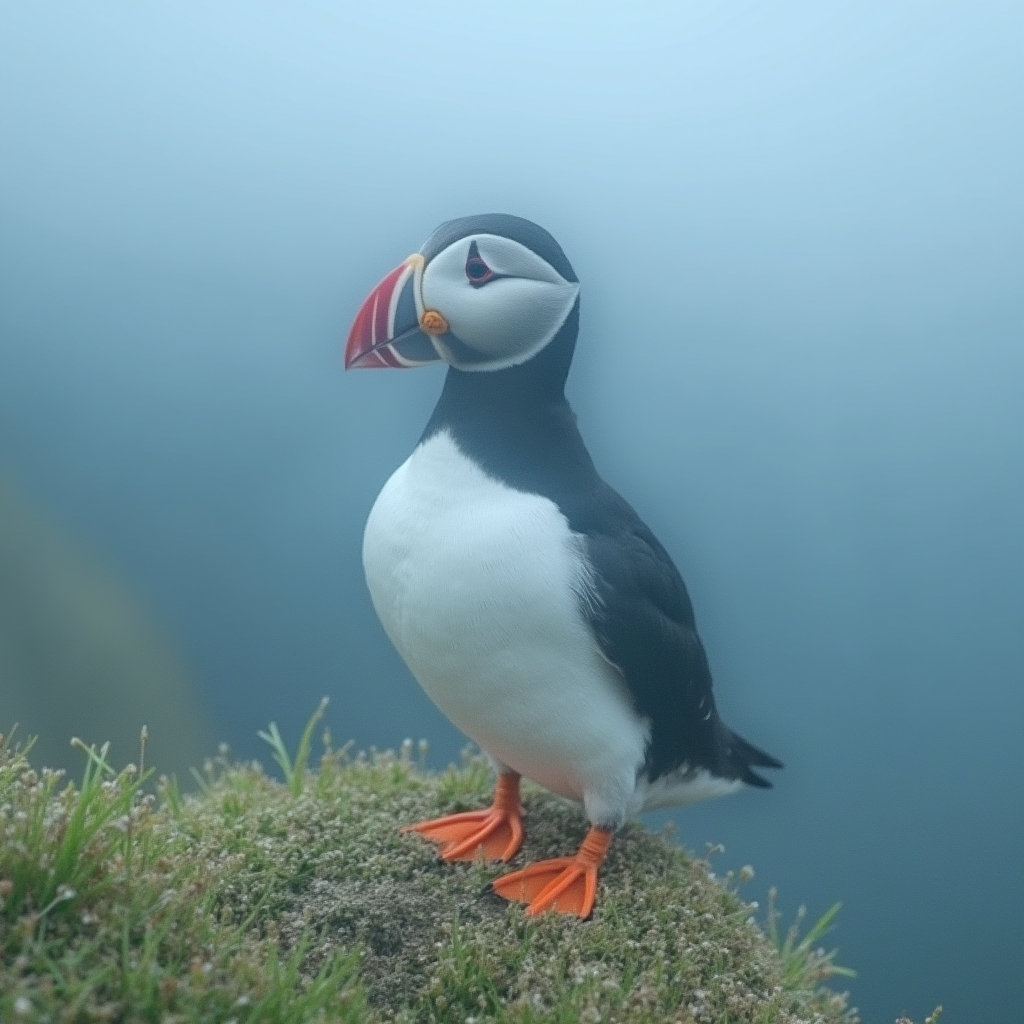

In [5]:
images.image